/tmp/ipykernel_2702/2145127233.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_gross.values, y=genre_gross.index, palette='viridis')


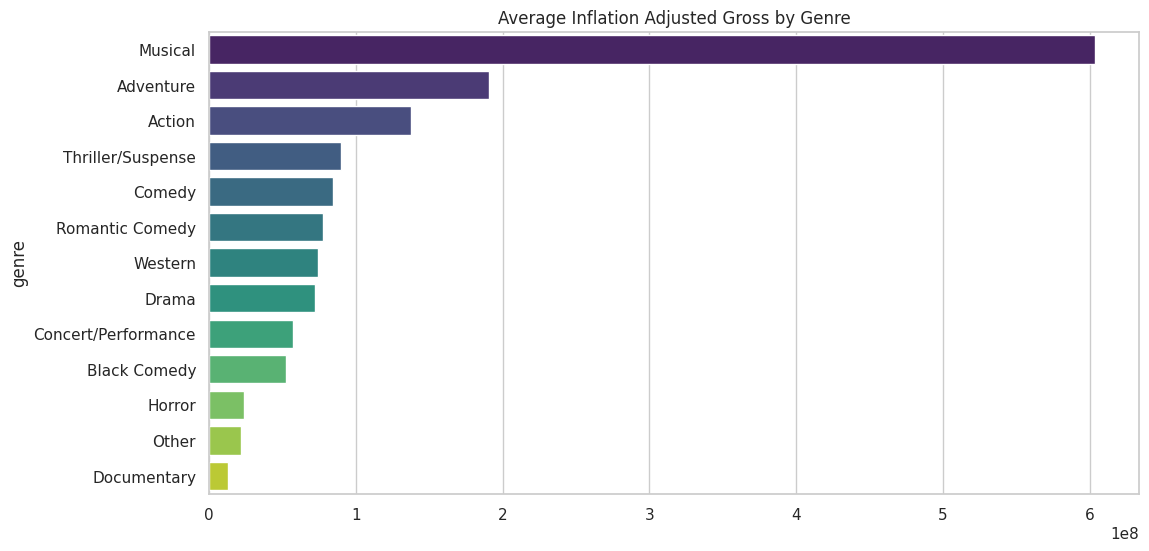

R2 Score: 0.6894


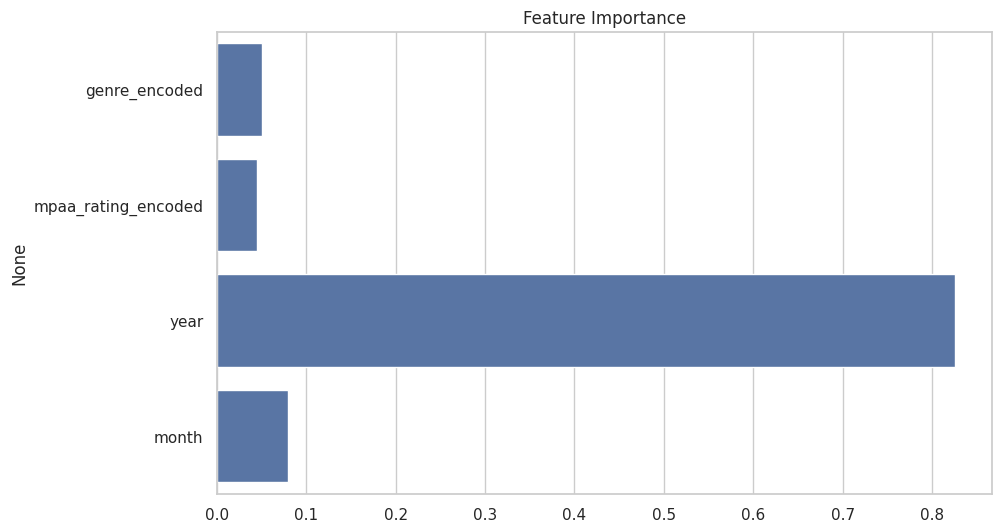

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('disney_movies.csv')
df['release_date'] = pd.to_datetime(df['release_date'])
df['year'] = df['release_date'].dt.year
df['month'] = df['release_date'].dt.month
df['genre'] = df['genre'].fillna('Other')
df['mpaa_rating'] = df['mpaa_rating'].fillna('Not Rated')
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
genre_gross = df.groupby('genre')['inflation_adjusted_gross'].mean().sort_values(ascending=False)
sns.barplot(x=genre_gross.values, y=genre_gross.index, palette='viridis')
plt.title('Average Inflation Adjusted Gross by Genre')
plt.show()
le_genre = LabelEncoder()
df['genre_encoded'] = le_genre.fit_transform(df['genre'])
le_rating = LabelEncoder()
df['mpaa_rating_encoded'] = le_rating.fit_transform(df['mpaa_rating'])
X = df[['genre_encoded', 'mpaa_rating_encoded', 'year', 'month']]
y = df['inflation_adjusted_gross']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
importances = model.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=X.columns)
plt.title('Feature Importance')
plt.show()